In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
credit_data = pd.read_csv('../data/cs-training.csv')
credit_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


the first column is useless(it repeats the id column but indexing starts with 1) and we should delete it

In [4]:
credit_data = credit_data.drop('Unnamed: 0', axis=1)
credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
credit_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

the dataset has only numerical dtypes so there is no need to use encoding. dataset has 2 columns with null values: MonthlyIncome an NumberOfDependents. 

In [6]:
credit_data.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
total_cells = np.prod(credit_data.shape)
total_missing = credit_data.isnull().sum().sum()
percent_missing = (total_missing/total_cells) * 100
percent_missing

np.float64(2.03969696969697)

only 2% of data is missing but still it is required to clean these 2 columns from null values

In [8]:
credit_data[['MonthlyIncome', 'NumberOfDependents']].describe()

,MonthlyIncome,NumberOfDependents
count,1.202690e+05,146076.000000
mean,6.670221e+03,0.757222
std,1.438467e+04,1.115086
min,0.000000e+00,0.000000
25%,3.400000e+03,0.000000
50%,5.400000e+03,0.000000
75%,8.249000e+03,1.000000
max,3.008750e+06,20.000000


In [9]:
def build_mean_median_chart(column, value_limit):
    median_val = credit_data[column].median()
    mean_val = credit_data[column].mean()

    plt.figure(figsize=(10, 4))

    sns.kdeplot(credit_data[column], color='dodgerblue', fill=True, alpha=0.15, label='Density')

    plt.axvline(x=median_val, color='green', linestyle='--', linewidth=3, label=f'Median: {median_val}')
    plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=3, label=f'Mean: {mean_val:.2f}')

    plt.xlim(0, value_limit)

    plt.title(f'Mean and median of {column}', fontsize=12)
    plt.xlabel(column, fontsize=10)
    plt.yticks([]) 
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(axis='x', alpha=0.5)

    plt.show()

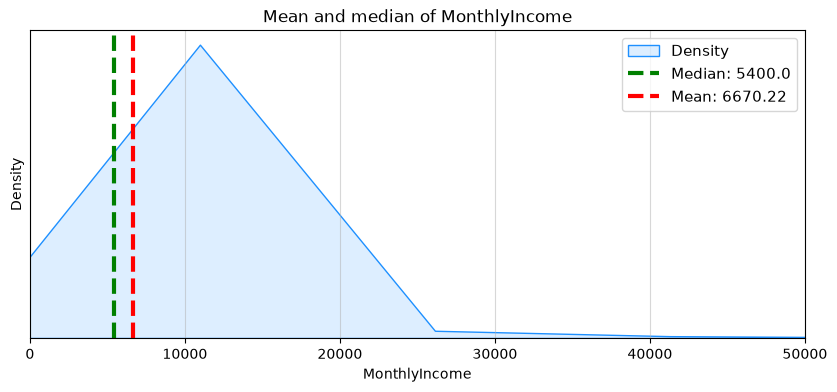

In [10]:
build_mean_median_chart('MonthlyIncome', 50000)

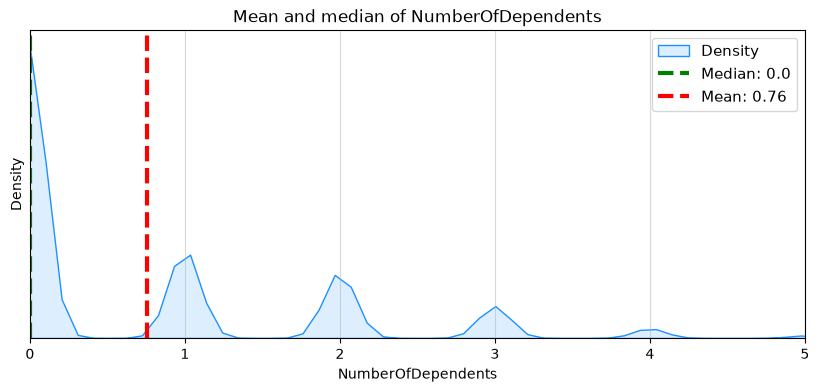

In [11]:
build_mean_median_chart('NumberOfDependents', 5)

median and mean are different (data is skewed) so it is safer to use median as a value for imputation

In [12]:
monthly_income_median = credit_data['MonthlyIncome'].median()
credit_data['MonthlyIncome'] = credit_data['MonthlyIncome'].fillna(monthly_income_median)

num_dependents_median = credit_data['NumberOfDependents'].median()
credit_data['NumberOfDependents'] = credit_data['NumberOfDependents'].fillna(num_dependents_median)

credit_data.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

now dataset doesn't have any missing values

In [13]:
credit_data.duplicated().sum().item()

767

dataset has 767 duplicated rows it may leads to overfitting. these rows should be deleted from dataset 

In [14]:
credit_data = credit_data.drop_duplicates()
credit_data.duplicated().sum().item()

0

In [15]:
credit_data.nunique()

SeriousDlqin2yrs                             2
RevolvingUtilizationOfUnsecuredLines    125728
age                                         86
NumberOfTime30-59DaysPastDueNotWorse        16
DebtRatio                               114194
MonthlyIncome                            13594
NumberOfOpenCreditLinesAndLoans             58
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
dtype: int64

In [16]:
credit_data.apply(lambda x: x.unique())

SeriousDlqin2yrs                                                                   [1, 0]
RevolvingUtilizationOfUnsecuredLines    [0.766126609, 0.957151019, 0.65818014, 0.23380...
age                                     [45, 40, 38, 30, 49, 74, 57, 39, 27, 51, 46, 7...
NumberOfTime30-59DaysPastDueNotWorse    [2, 0, 1, 3, 4, 5, 7, 10, 6, 98, 12, 8, 9, 96,...
DebtRatio                               [0.802982129, 0.121876201, 0.085113375, 0.0360...
MonthlyIncome                           [9120.0, 2600.0, 3042.0, 3300.0, 63588.0, 3500...
NumberOfOpenCreditLinesAndLoans         [13, 4, 2, 5, 7, 3, 8, 9, 6, 10, 14, 22, 17, 1...
NumberOfTimes90DaysLate                 [0, 1, 3, 2, 5, 4, 98, 10, 9, 6, 7, 8, 15, 96,...
NumberRealEstateLoansOrLines            [6, 0, 1, 3, 4, 2, 5, 8, 7, 9, 17, 15, 10, 12,...
NumberOfTime60-89DaysPastDueNotWorse           [0, 1, 2, 5, 3, 98, 4, 6, 7, 8, 96, 11, 9]
NumberOfDependents                      [2.0, 1.0, 0.0, 3.0, 4.0, 5.0, 6.0, 8.0, 7.0, ...
dtype: obj

In [17]:
credit_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149233.000000,149233.000000,149233.000000,149233.000000,149233.000000,1.492330e+05,149233.000000,149233.000000,149233.000000,149233.000000,149233.000000
mean,0.067036,6.077045,52.298145,0.388386,354.808254,6.426774e+03,8.488082,0.232435,1.023473,0.206811,0.741177
std,0.250085,250.396053,14.714050,3.779712,2042.891693,1.292246e+04,5.134233,3.752133,1.130304,3.736132,1.108596
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030210,41.000000,0.000000,0.178098,3.900000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154285,52.000000,0.000000,0.368578,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.555959,63.000000,0.000000,0.877090,7.409000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


/var/folders/ls/lmkg84h154l871cbkwhq2nnc0000gn/T/ipykernel_46155/1413375657.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=credit_data, x='SeriousDlqin2yrs', palette='Set2')


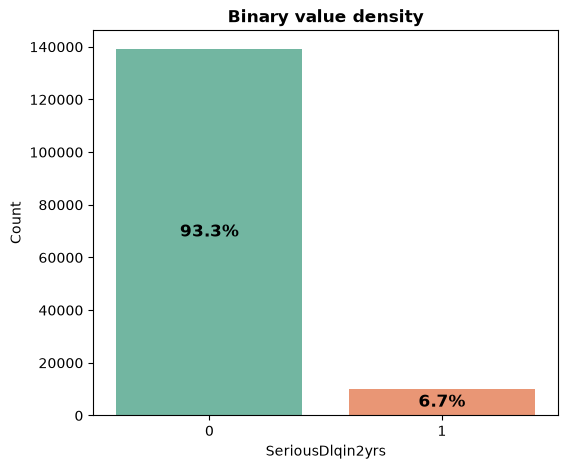

In [24]:
plt.figure(figsize=(6, 5))
 
ax = sns.countplot(data=credit_data, x='SeriousDlqin2yrs', palette='Set2')

total = len(credit_data['SeriousDlqin2yrs'])

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    
    ax.annotate(
        percentage, 
        (p.get_x() + p.get_width() / 2., p.get_height() / 2.), 
        ha='center', 
        va='center', 
        xytext=(0, 0), 
        textcoords='offset points',
        fontsize=12, 
        fontweight='bold', 
        color='black' 
    )


plt.title('Binary value density', fontsize=12, fontweight='bold')
plt.xlabel('SeriousDlqin2yrs', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.show()

now we can see that mostly (93.3%) people pay in time  